In [46]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
from matplotlib.colors import TwoSlopeNorm 

In [47]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
ds

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lon_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lon_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
    lat_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
  * time        (time) float32 4B 1.339e+06
Dimensions without coordinates: auxil
Data variables: (12/54)
    spherical   |S1 1B ...
    xl          float64 8B ...
    el          float64 8B ...
    Vtransform  float64 8B ...
    sc_r        (s_rho) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
    sc_w        (s_w) float64 264B dask.array<chunksize=(33,), meta=np.ndarray>
    ...          ...
    swflux      (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    radsw       (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_rlw   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_lat   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_sen   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    hel         (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
Attributes: (12/57)
    type:           ROMS restart file
    title:          Peru UW Interannual Run
    date:           
    rst_file:       croco_rst.nc
    his_file:       croco_his.nc
    avg_file:       croco_avg.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL PERU_UW MPI OBC_WEST OBC_NORTH OBC_SOUTH BIOLOGY...

## Functions

In [48]:
## kml to struct
def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [49]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

## Lon and lat for the whole dataset
lat = np.linspace(-33.0, 10.03286, 542).reshape(542, 1)  # Reshape to match eta_rho
lon = np.linspace(-118.9083, -68.90833, 602).reshape(1, 602)  # Reshape to match xi_rho

lats, lons = np.meshgrid(lat.flatten(), lon.flatten(), indexing="ij")

LON=lons
LAT=lats
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

In [50]:
Puertos = {
    "Pisco":  [-13.69388889,  -76.22416667],
    "Callao":   [-12.0575,  -77.15305556],
    "Chimbote": [-9.076666667,  -78.61472222],
    "Paita":    [-5.078055556,  -81.10638889],
    }

In [51]:
##Normalize
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())

## seasonality
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

## Load Upwelling Indices

In [52]:
## generate time
time = pd.date_range(start='1980-01', end='2016-01', freq='M')
##------CUI_model
CUI = loadmat("../../NHCS/Processed/CUI_SST_index.mat")
CUI_cc = np.array(CUI['CUI_SSTi']).squeeze()
lati_cc = np.array(CUI['lati']).squeeze()
##----Ekman 
Ekman_data = loadmat("../../NHCS/Processed/EKMAN_components.mat")
Ek_pump = Ekman_data['EK_pump']
# ## Ekman transport
Ek_tr = Ekman_data['UEK']*-1

#----- Analytical Velocity
AV_data = loadmat("../../NHCS/Processed/AV.mat")
Coastal_up = loadmat("../../NHCS/Processed/Coastal_upwelling.mat")

#----- CUTI
CUTI_data = loadmat("../../NHCS/Processed/CUTI.mat")

#-------- BEUTI
BEUTI_data = loadmat("../../NHCS/Processed/BEUTI.mat")

#-------- BUI 
BUI_data = loadmat("../../NHCS/Processed/BUI.mat")

#----- CROCO wmld
WMLD_data = loadmat("../../NHCS/Processed/WMLD_MLD.mat")

CUI_ds = xr.DataArray(
    data=CUI_cc.T,  # numpy array of Mean_CUI
    dims=["time",'lat'],  # Dimension matches the time in CUI_MAX
    coords={"time": time,
           'lat': lati_cc},  # Ensure matching time coordinates
    name="CUI_cc"  # Name for the variable
)

/tmp/ipykernel_3168950/2426928416.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='1980-01', end='2016-01', freq='M')


In [63]:
UI_ds = xr.Dataset(
    data_vars={
        'WMLD': (("time", "lat","lon"), WMLD_data['WMLD'].transpose(2, 0, 1)),
        'Ekman_pump': (("time", "lat","lon"), Ek_pump.transpose(2, 1, 0)),
        'Ekman_transport':(("time", "lat","lon"), Ek_tr.transpose(2, 1, 0)),
        'AV': (("time", "lat","lon"), AV_data['W_analytical'].transpose(2, 1, 0)),
        # 'CUpwelling':(('time','lat','lon'),Coastal_up['WcMean'].transpose(2, 1, 0)),
        # 'HUI': (("time", "lat","lon"), HUI_data['HUI'].transpose(2, 1, 0)),
        'CUTI': (("time", "lat","lon"), CUTI_data['CUTI'].transpose(2, 1, 0) *-1),
        'BEUTI': (("time", "lat","lon"), BEUTI_data['BEUTI'].transpose(2, 1, 0) *-1),
        'BUI': (("time", "lat","lon"), BUI_data['BUI'].transpose(2, 1, 0)),        
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)

UI_ds = UI_ds * inshore_mask *mask_nan

In [64]:
UI_ds = UI_ds.mean(dim='lon',skipna=True).sel(lat=slice(-16,-5))
UI_ds['CUI'] = CUI_ds.sel(lat=slice(-16,-5))
UI_ds

<xarray.Dataset> Size: 3MB
Dimensions:          (lat: 134, time: 432)
Coordinates:
  * lat              (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.159 -5.076
  * time             (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    WMLD             (time, lat) float64 463kB 3.846e-06 3.893e-06 ... 5.546e-06
    Ekman_pump       (time, lat) float64 463kB 5.013e-06 5.36e-06 ... 6.537e-06
    Ekman_transport  (time, lat) float64 463kB 1.039 0.9855 ... 4.725 4.869
    AV               (time, lat) float64 463kB 7.759e-06 7.874e-06 ... 1.259e-05
    CUTI             (time, lat) float64 463kB 1.172 1.208 1.173 ... 4.812 4.949
    BEUTI            (time, lat) float64 463kB 4.42 5.478 5.382 ... 49.42 51.6
    BUI              (time, lat) float64 463kB 0.3939 0.3735 0.4 ... 1.791 1.845
    CUI              (time, lat) float32 232kB 1.252 1.419 1.36 ... 1.777 1.826

In [65]:
UI_season = seasonality(UI_ds)
UI_season

<xarray.Dataset> Size: 98kB
Dimensions:          (month: 12, lat: 134)
Coordinates:
  * lat              (lat) float64 1kB -15.95 -15.87 -15.79 ... -5.159 -5.076
  * month            (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    WMLD             (month, lat) float64 13kB 3.082e-06 3.398e-06 ... 1.002e-05
    Ekman_pump       (month, lat) float64 13kB 6.196e-06 6.406e-06 ... 5.654e-06
    Ekman_transport  (month, lat) float64 13kB 1.062 1.011 1.086 ... 3.384 3.537
    AV               (month, lat) float64 13kB 8.77e-06 8.785e-06 ... 1.01e-05
    CUTI             (month, lat) float64 13kB 1.185 1.207 1.209 ... 3.453 3.603
    BEUTI            (month, lat) float64 13kB 4.706 5.189 4.977 ... 35.51 37.15
    BUI              (month, lat) float64 13kB 0.4026 0.3831 ... 1.283 1.34
    CUI              (month, lat) float32 6kB 0.6849 0.7978 ... 1.752 1.754

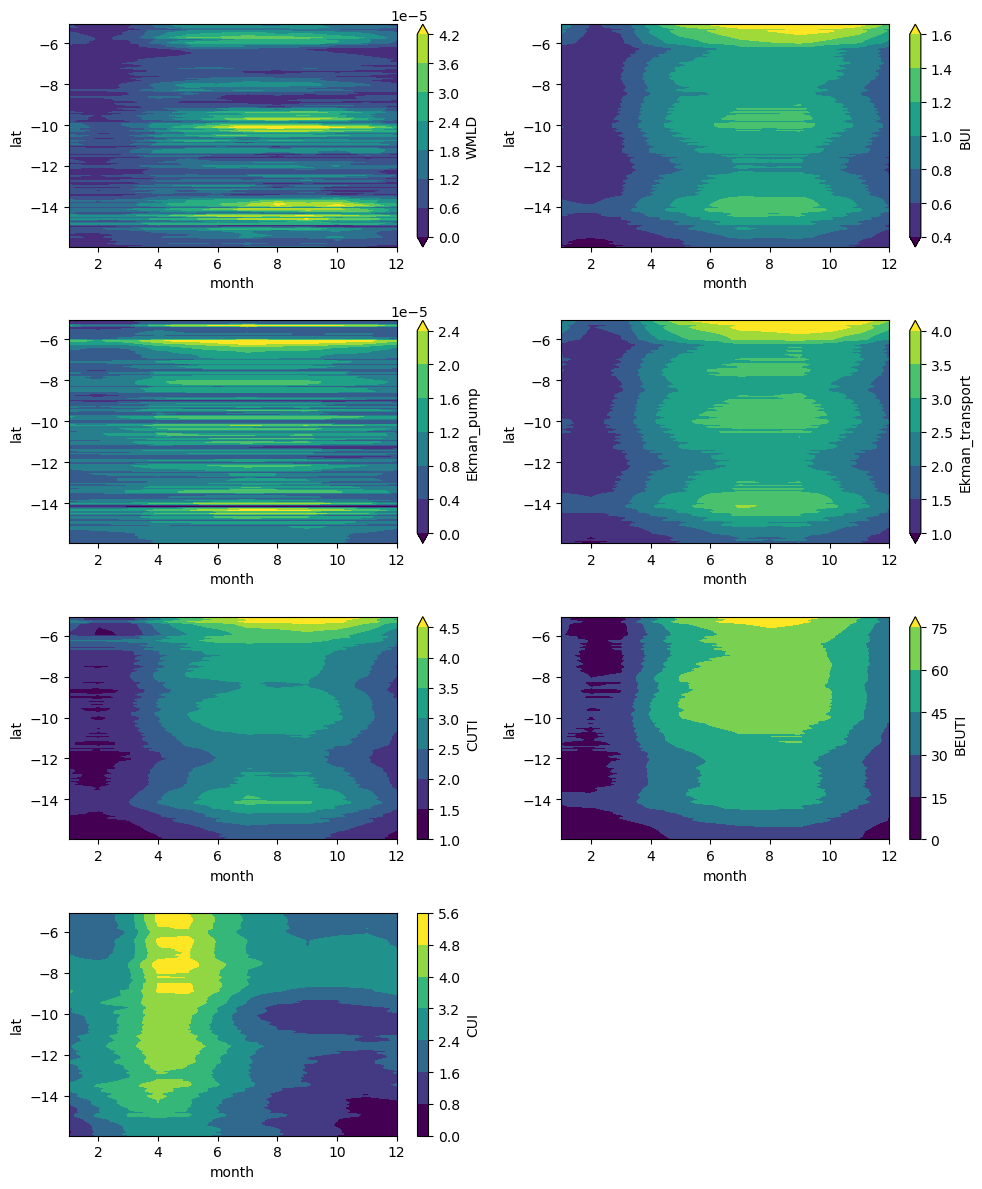

In [72]:
# fig,ax = plt.subplots(4,2,figsize=(10,10))

# UI_season.WMLD.plot.contourf(x='month',y='lat',robust=True,ax=ax[0])
# UI_season.BUI.plot.contourf(x='month',y='lat',robust=True,ax=ax[1])
# UI_season.Ekman_pump.plot.contourf(x='month',y='lat',robust=True,ax=ax[2])
# UI_season.Ekman_transport.plot.contourf(x='month',y='lat',robust=True,ax=ax[3])
# UI_season.CUTI.plot.contourf(x='month',y='lat',robust=True,ax=ax[4])
# UI_season.BEUTI.plot.contourf(x='month',y='lat',robust=True,ax=ax[5])
# UI_season.CUI.plot.contourf(x='month',y='lat',robust=True,ax=ax[6])

fig, ax = plt.subplots(4, 2, figsize=(10, 12))
# accede a cada subplot directamente

UI_season.WMLD.plot.contourf(x='month', y='lat', robust=True, ax=ax[0, 0])
UI_season.BUI.plot.contourf(x='month', y='lat', robust=True, ax=ax[0, 1])
UI_season.Ekman_pump.plot.contourf(x='month', y='lat', robust=True, ax=ax[1, 0])
UI_season.Ekman_transport.plot.contourf(x='month', y='lat', robust=True, ax=ax[1, 1])
UI_season.CUTI.plot.contourf(x='month', y='lat', robust=True, ax=ax[2, 0])
UI_season.BEUTI.plot.contourf(x='month', y='lat', robust=True, ax=ax[2, 1])
UI_season.CUI.plot.contourf(x='month', y='lat', robust=True, ax=ax[3, 0])

# Elimina el subplot vacío (posición 4,1)
fig.delaxes(ax[3, 1])

plt.tight_layout()
plt.show()


/tmp/ipykernel_3168950/1952818109.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels,fontsize=16)


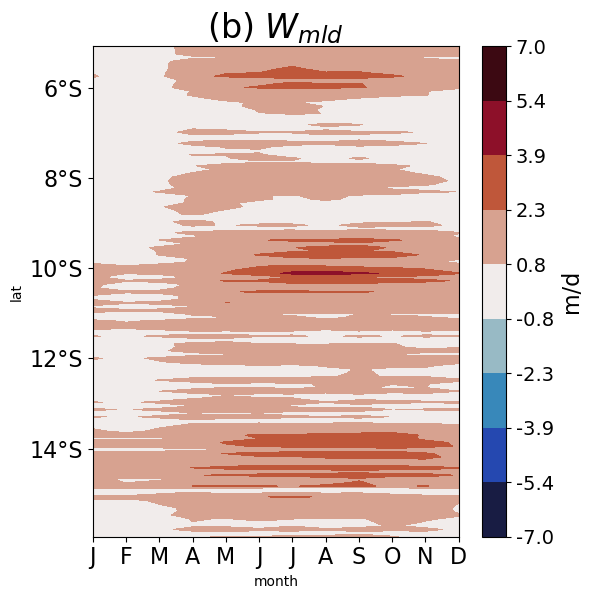

In [60]:

fig, ax = plt.subplots(figsize=(6,6))

# np.linspace(-5, 5, 10) 
vmin=-7; vmax=7
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

levels=np.linspace(vmin,vmax,10)

cf=UI_season.WMLD.plot.contourf(x='month',vmin=vmin, vmax=vmax,cmap = cm.balance,
                                                                 norm=norm,levels=levels,add_colorbar=False)
ax = plt.gca()
cbar = plt.colorbar(cf, ax=ax)
cbar.set_label('m/d',fontsize=16)
cbar.ax.set_yticklabels([f"{tick:.1f}" for tick in levels], fontsize=14)  # 1 decimal formatting

yticks = ax.get_yticks()  # Get current y-tick positions

# Format labels with °S for negative values (Southern Hemisphere)
new_labels = [f"{-y:.0f}°S" if y < 0 else f"{y:.0f}°N" for y in yticks]
ax.set_yticklabels(new_labels,fontsize=16)

plt.title('(b) $W_{mld}$',fontsize=24)
plt.tight_layout()

months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
plt.xticks(range(1, 13), months,fontsize=16)  # Assuming your data has 12 points (one per month)

# plt.savefig('Figures/wmld_season_poster'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()